# STAC + VirtualiZarr (Sentinel-2)

End-to-end example: query a STAC API for Sentinel COGs in California spanning
two adjacent UTM zones (10N and 11N), then merge them into a single grid using
`merge(datafusion=True, virtualize=...)`.

Virtualization happens **lazily** — COGs are virtualized on-the-fly during
`compute()` via the `default_virtualizer` callback, so only sources that
intersect the target grid are processed and only when they don't already exist.

The UTM zone boundary runs roughly along **-120° longitude** through the
Sierra Nevada. We pick a bbox around Lake Tahoe that straddles both zones.


**AWS credentials:** This notebook reads from the public `e84-earth-search-sentinel-data` bucket
(requester-pays) in `us-west-2`. You need valid AWS credentials configured.

In [1]:
import warnings

import matplotlib.pyplot as plt
import xarray as xr
from affine import Affine
from rasterix import RasterIndex

from lazymerge.merge import merge
from lazymerge.virtualize import default_virtualizer

warnings.filterwarnings("ignore")
xr.set_options(display_expand_indexes=True)

## 1. Configure cloud storage

Sentinel-2 data lives in the `e84-earth-search-sentinel-data` S3 bucket
(requester-pays, `us-west-2`).

In [2]:
import boto3
from obspec_utils.registry import ObjectStoreRegistry
from obstore.auth.boto3 import Boto3CredentialProvider
from obstore.store import S3Store

scheme = "s3://"
bucket = "e84-earth-search-sentinel-data"
region = "us-west-2"

session = boto3.Session()
object_store = S3Store(
    bucket=bucket,
    region=region,
    request_payer=True,
    credential_provider=Boto3CredentialProvider(session=session),
)
registry = ObjectStoreRegistry({f"{scheme}{bucket}": object_store})

## 2. Set up Icechunk repository

Icechunk provides a versioned zarr store that supports virtual chunk references
back to the original COG files on S3.

In [3]:
import icechunk

location = "data/icechunk_california"
storage = icechunk.local_filesystem_storage(location)

config = icechunk.RepositoryConfig.default()
config.caching = icechunk.CachingConfig(
    num_bytes_chunks=500_000_000,  # 500 MB chunk data cache
)
s3_chunk_store = icechunk.s3_store(
    region=region,
    requester_pays=True,
)
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(f"{scheme}{bucket}/", s3_chunk_store),
)
credentials = icechunk.containers_credentials(
    {f"{scheme}{bucket}/": icechunk.s3_credentials(from_env=True)},
)
repo = icechunk.Repository.open_or_create(
    storage=storage,
    config=config,
    authorize_virtual_chunk_access=credentials,
)
ic_session = repo.writable_session("main")

  2026-05-29T19:00:35.363936Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:92



## 3. Ingest STAC search results

Search Sentinel scenes and ingest the metadata with the `red`, `green`, and `blue` asset hrefs.

In [4]:
from zarr_datafusion_search import ingest_stac_search

rows = await ingest_stac_search(
    url="https://earth-search.aws.element84.com/v1",
    session=ic_session,
    bbox=(-121.5, 38.5, -118.5, 40.5),
    datetime="2025-10-01/2025-10-15",
    collections=["sentinel-2-c1-l2a"],
    max_items=10,
    asset_hrefs=["red", "green", "blue"],
    query={"eo:cloud_cover": {"lt": 10}},
)
rows

10

## 4. Query metadata with DataFusion

Use DataFusion SQL to inspect the ingested metadata and verify we have
scenes in both UTM zones.

In [5]:
from datafusion import SessionContext
from geodatafusion import register_all
from zarr_datafusion_search import ZarrTable

ic_session = repo.writable_session("main")
zarr_table = await ZarrTable.from_icechunk(session=ic_session, group_path="/meta")

ctx = SessionContext()
register_all(ctx)
ctx.register_table_provider("meta", zarr_table)

df = ctx.sql(
    "SELECT * FROM meta ORDER BY datetime",
)
df

asset_blue,asset_green,asset_red,bbox,constellation,created,datetime,earthsearch:payload_id,eo:cloud_cover,grid:code,id,mgrs:grid_square,mgrs:latitude_band,mgrs:utm_zone,platform,proj:epsg,s2:cloud_shadow_percentage,s2:datastrip_id,s2:datatake_id,s2:datatake_type,s2:degraded_msi_data_percentage,s2:generation_time,s2:high_proba_clouds_percentage,s2:medium_proba_clouds_percentage,s2:nodata_pixel_percentage,s2:not_vegetated_percentage,s2:processing_baseline,s2:product_type,s2:product_uri,s2:reflectance_conversion_factor,s2:saturated_defective_pixel_percentage,s2:snow_ice_percentage,s2:thin_cirrus_percentage,s2:tile_id,s2:unclassified_percentage,s2:vegetation_percentage,s2:water_percentage,storage:platform,storage:region,storage:requester_pays,updated,view:azimuth,view:incidence_angle,view:sun_azimuth,view:sun_elevation
https://e84-earth-search-https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/11/T/KE/2025/10/S2C_T11TKE_20251012T184845_L2A/B02.tif...,https://e84-earth-search-https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/11/T/KE/2025/10/S2C_T11TKE_20251012T184845_L2A/B03.tif...,https://e84-earth-search-https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/11/T/KE/2025/10/S2C_T11TKE_20251012T184845_L2A/B04.tif...,"b'\x01\x03\x00\x00\x00\x0b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00\x00\x00,\x9b9$\xb5\x1e^\xc0p\x0b\x96\xea\x02\xceC@\x99a\xa3\xac\xdf\xcd]\xc0p\x0b\x96\xea\x02\xceC@\x99a\xa3\xac\xdf\xcd]\xc0\xb8\x92\x1d\x1b\x81PD@,\x9b9$\xb5\x1e^\xc0\xb8\x92\x1d\x1b\x81PD@,\x9b9$\xb5\x1e^\xc0p\x0b\x96\xea\x02\xceC@'...",sentinel-2,2025-10-13 00:15:55.321002025-10-13 00:15:55.321000...,2025-10-12 18:53:34.825002025-10-12 18:53:34.825000...,roda-sentinel-2-c1-l2a/woroda-sentinel-2-c1-l2a/workflow-sentinel-2-c1-l2a-to-stac/ecfd606cb24393f5cbc65f4488dcf185...,0.234831,MGRS-11TKE,S2C_T11TKE_20251012T18484S2C_T11TKE_20251012T184845_L2A...,KE,T,11,sentinel-2c,32611,0.003685,S2C_OPER_MSI_L2A_DS_2CPS_S2C_OPER_MSI_L2A_DS_2CPS_20251012T220220_S20251012T184845_N05.11...,GS2C_20251012T184341_0057GS2C_20251012T184341_005760_N05.11...,INS-NOBS,0.0134,2025-10-12T22:02:20.000002025-10-12T22:02:20.000000Z...,0.049996,0.106056,14.551552,90.295559,05.11,S2MSI2A,S2C_MSIL2A_20251012T18434S2C_MSIL2A_20251012T184341_N0511_R070_T11TKE_20251012T220220.SAFE...,1.00270392241554,0,3.5e-05,0.078779,S2C_OPER_MSI_L2A_TL_2CPS_S2C_OPER_MSI_L2A_TL_2CPS_20251012T220220_A005760_T11TKE_N05.11...,0.044552,4.145623,4.957866,AWS,us-west-2,False,2025-10-13 00:15:55.321002025-10-13 00:15:55.321000...,103.39706481599862,8.226388589336729,162.817826061657,40.6701397768753
https://e84-earth-search-https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/10/T/GK/2025/10/S2C_T10TGK_20251012T184845_L2A/B02.tif...,https://e84-earth-search-https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/10/T/GK/2025/10/S2C_T10TGK_20251012T184845_L2A/B03.tif...,https://e84-earth-search-https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/10/T/GK/2025/10/S2C_T10TGK_20251012T184845_L2A/B04.tif...,b'\x01\x03\x00\x00\x00\x0b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00\x00\x00\xf2z0)>\x1e^\xc0\x93nK\xe4\x82\xcdC@\xf3!\xa8\x1a\xbd\xd5]\xc0\x93nK\xe4\x82\xcdC@\xf3!\xa8\x1a\xbd\xd5]\xc0\x03|\xb7y\xe3ND@\xf2z0)>\x1e^\xc0\x03|\xb7y\xe3ND@\xf2z0)>\x1e^\xc0\x93nK\xe4\x82\xcdC@'...,sentinel-2,2025-10-13 00:48:17.423002025-10-13 00:48:17.423000...,2025-10-12 18:53:35.190002025-10-12 18:53:35.190000...,roda-sentinel-2-c1-l2a/woroda-sentinel-2-c1-l2a/workflow-sentinel-2-c1-l2a-to-stac/fefe140d53c1552182fb4a0dcdae9773...,0.279838,MGRS-10TGK,S2C_T10TGK_20251012T18484S2C_T10TGK_20251012T184845_L2A...,GK,T,10,sentinel-2c,32610,0.003699,S2C_OPER_MSI_L2A_DS_2CPS_S2C_OPER_MSI_L2A_DS_2CPS_20251012T220220_S20251012T184845_N05.11...,GS2C_20251012T184341_0057GS2C_20251012T184341_005760_N05.11...,INS-NOBS,0.0143,2025-10-12T22:02:20.00

## 5. Create virtualizer

Create a `default_virtualizer` callback that will lazily virtualize COGs
during merge. Pass `target_resolution` to automatically select the best COG
overview level for the output grid — only level 0 (full resolution) and the
optimal overview are virtualized, avoiding unnecessary work.

Virtualization is deferred — nothing happens until `compute()` is called,
and only sources that intersect each target chunk are virtualized.

This virtualization step only happens once so subsequent calls will only need to read data and won't need to virtualize sources and will be significantly faster.

In [6]:
virtualizer = default_virtualizer(registry, target_resolution=20.0)

## 6. Lazy merge

Define a target grid in **UTM 11N** (EPSG:32611) covering the Lake Tahoe area.
Sources in UTM 10N will be reprojected on the fly during merge.

The `virtualize` callback triggers lazy VirtualiZarr creation — each source
COG is virtualized into the Icechunk store the first time a chunk needs it.
Coordination ensures each source is virtualized exactly once, even when
multiple chunks reference the same source concurrently.

In [7]:
bands = ["red", "green", "blue"]
result_arr, result_spatial, result_proj, time_coords = merge(
    store=ic_session.store,
    crs="EPSG:32611",
    bbox=(200000.0, 4260000.0, 340000.0, 4490000.0),
    resolution=20.0,
    chunk_size=(1024, 1024),
    bands=bands,
    datafusion=True,
    sortby="datetime",
    temporal_grouping="P1D",
    nodata=0,
    virtualize=virtualizer,
)
result_arr

,Array,Chunk
Bytes,966.0 MB,4.2 MB
Shape,"(1, 3, 11500, 7000)","(1, 1, 1024, 1024)"
Count,3 arrays in Plan,252 Chunks
Type,float32,np.ndarray


## 7. Open the lazy Cubed array with xarray

In [9]:
da = xr.DataArray(result_arr, dims=["time", "bands", "y", "x"])

affine = Affine(*result_spatial.transform)
raster_idx = RasterIndex.from_transform(
    affine=affine,
    width=da.sizes["x"],
    height=da.sizes["y"],
    x_dim="x",
    y_dim="y",
    crs=result_proj.code,
)
coords = xr.Coordinates.from_xindex(raster_idx)
da = da.assign_coords(coords)
da = da.proj.assign_crs(spatial_ref=result_proj.code, allow_override=True)
da = da.assign_coords({"time": time_coords, "bands": bands})
da

,Array,Chunk
Bytes,966.0 MB,4.2 MB
Shape,"(1, 3, 11500, 7000)","(1, 1, 1024, 1024)"
Count,3 arrays in Plan,252 Chunks
Type,float32,np.ndarray


## 8. Compute and visualize

Compute to materialize the array and then plot it. **This is where
virtualization actually happens** — each chunk task virtualizes any
sources it needs before reading pixel data.

In [ ]:
import logging

logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

In [10]:
da = da.compute()
da

INFO:lazymerge.virtualize:Virtualized S2C_T11TKE_20251012T184845_L2A (3 bands, levels [0], native_res=10.1)
INFO:lazymerge.virtualize:Virtualized S2C_T10TGK_20251012T184845_L2A (3 bands, levels [0, 1], native_res=9.2)
INFO:lazymerge.virtualize:Virtualized S2C_T11SLD_20251012T184845_L2A (3 bands, levels [0], native_res=10.4)
INFO:lazymerge.virtualize:Virtualized S2C_T11SKD_20251012T184845_L2A (3 bands, levels [0], native_res=10.6)
INFO:lazymerge.virtualize:Virtualized S2C_T10SGJ_20251012T184845_L2A (3 bands, levels [0], native_res=10.7)
INFO:lazymerge.virtualize:Virtualized S2C_T11SKC_20251012T184845_L2A (3 bands, levels [0], native_res=10.6)
INFO:lazymerge.virtualize:Virtualized S2C_T11SLC_20251012T184845_L2A (3 bands, levels [0], native_res=10.4)
INFO:lazymerge.virtualize:Virtualized S2C_T10SGH_20251012T184845_L2A (3 bands, levels [0], native_res=10.6)


<xarray.DataArray 'array-004' (time: 1, bands: 3, y: 11500, x: 7000)> Size: 966MB
array([[[[  nan,   nan,   nan, ...,   nan,   nan,   nan],
         [  nan,   nan,   nan, ...,   nan,   nan,   nan],
         [  nan,   nan,   nan, ...,   nan,   nan,   nan],
         ...,
         [1271., 1211., 1138., ..., 2332., 2362., 2062.],
         [1505., 1561., 1194., ..., 1794., 1809., 1902.],
         [1490., 1418., 1238., ..., 2128., 2092., 1834.]],

        [[  nan,   nan,   nan, ...,   nan,   nan,   nan],
         [  nan,   nan,   nan, ...,   nan,   nan,   nan],
         [  nan,   nan,   nan, ...,   nan,   nan,   nan],
         ...,
         [1393., 1301., 1160., ..., 2246., 2180., 1974.],
         [1512., 1540., 1304., ..., 1832., 1746., 1852.],
         [1504., 1386., 1297., ..., 2018., 1966., 1787.]],

        [[  nan,   nan,   nan, ...,   nan,   nan,   nan],
         [  nan,   nan,   nan, ...,   nan,   nan,   nan],
         [  nan,   nan,   nan, ...,   nan,   nan,   nan],
         ...,
         [1112., 1102., 1045., ..., 1905., 1935., 1750.],
         [1225., 1232., 1081., ..., 1567., 1631., 1644.],
         [1244., 1186., 1086., ..., 1740., 1700., 1578.]]]],
      shape=(1, 3, 11500, 7000), dtype=float32)
Coordinates:
  * time         (time) datetime64[s] 8B 2025-10-12
  * bands        (bands) <U5 60B 'red' 'green' 'blue'
  * y            (y) float64 92kB 4.49e+06 4.49e+06 ... 4.26e+06 4.26e+06
  * x            (x) float64 56kB 2e+05 2e+05 2e+05 ... 3.4e+05 3.4e+05 3.4e+05
  * spatial_ref  int64 8B 0
Indexes:
  ┌ x            RasterIndex (crs=EPSG:32611)
  └ y
    spatial_ref  CRSIndex (crs=EPSG:32611)

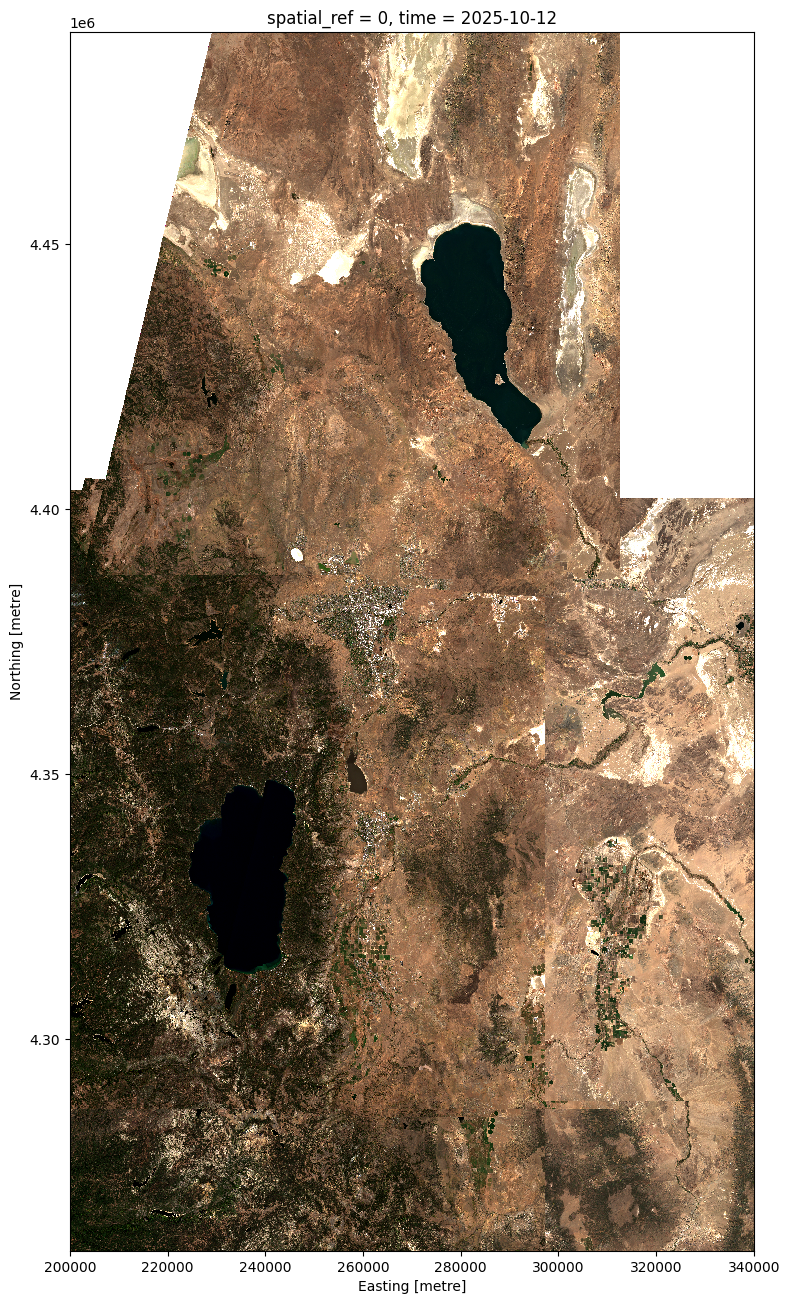

In [11]:
da = da.sel(time="2025-10-12")
width = 8
height = width * da.sizes["y"] / da.sizes["x"]
da.plot.imshow(rgb="bands", robust=True, figsize=(width, height))
plt.tight_layout()